In [1]:
import pandas as pd
df=pd.read_csv('tira_campaign_data_with_nulls.csv')
df

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,TI-CMP-1000,SEO,Working Women,11.0,NaN,64004.0,2906.0,1639.0,952.0,222768.0,129.72,0.80,Tamil,NaN,Premium Shoppers,30-10-2024
1,TI-CMP-1001,Social Media,Tier 2 City Customers,24.0,YouTube,71795.0,2051.0,552.0,256.0,199168.0,316.36,1.46,Tamil,3.98,College Students,11-09-2024
2,TI-CMP-1002,NaN,Working Women,28.0,NaN,79158.0,3546.0,1928.0,1314.0,433620.0,NaN,2.62,English,8.58,Tier 2 City Customers,28-08-2024
3,TI-CMP-1003,Email,Youth,8.0,Google,31523.0,3721.0,2088.0,736.0,571872.0,161.13,3.82,Bengali,20.76,Youth,27-07-2024
4,TI-CMP-1004,Paid Ads,Premium Shoppers,15.0,"Facebook, Email, WhatsApp",61441.0,7277.0,3615.0,2602.0,1477936.0,82.07,NaN,Tamil,21.96,College Students,19-12-2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55550,NaN,NaN,Tier 2 City Customers,11.0,"Instagram, YouTube, Email",NaN,3799.0,NaN,1099.0,454986.0,213.21,0.94,Bengali,10.70,Youth,12-11-2024
55551,TI-CMP-56551,SEO,Working Women,20.0,"Google, Instagram",54886.0,1578.0,634.0,NaN,136514.0,436.24,-0.09,English,4.66,Working Women,25-08-2024
55552,TI-CMP-56552,Email,NaN,13.0,"Facebook, Instagram",97954.0,11480.0,4567.0,2144.0,445952.0,78.77,1.64,NaN,18.57,Premium Shoppers,15-04-2025
55553,NaN,Influencer,Premium Shoppers,22.0,"Google, Email",11669.0,NaN,122.0,44.0,26884.0,NaN,-0.76,English,5.35,Working Women,21-07-2024


In [2]:
df=df.drop_duplicates()

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       52822 non-null  str    
 1   Campaign_Type     52846 non-null  str    
 2   Target_Audience   52891 non-null  str    
 3   Duration          52890 non-null  float64
 4   Channel_Used      52822 non-null  str    
 5   Impressions       52832 non-null  float64
 6   Clicks            52825 non-null  float64
 7   Leads             52898 non-null  float64
 8   Conversions       52895 non-null  float64
 9   Revenue           52826 non-null  float64
 10  Acquisition_Cost  52905 non-null  float64
 11  ROI               52813 non-null  float64
 12  Language          52769 non-null  str    
 13  Engagement_Score  52825 non-null  float64
 14  Customer_Segment  52844 non-null  str    
 15  Date              52865 non-null  str    
dtypes: float64(9), str(7)
memory usage: 10.9 MB


In [4]:
null_info = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2),
    'dtype': df.dtypes
})

print(null_info[null_info['null_count'] > 0])

                  null_count  null_%    dtype
Campaign_ID             2733    4.92      str
Campaign_Type           2709    4.88      str
Target_Audience         2664    4.80      str
Duration                2665    4.80  float64
Channel_Used            2733    4.92      str
Impressions             2723    4.90  float64
Clicks                  2730    4.91  float64
Leads                   2657    4.78  float64
Conversions             2660    4.79  float64
Revenue                 2729    4.91  float64
Acquisition_Cost        2650    4.77  float64
ROI                     2742    4.94  float64
Language                2786    5.01      str
Engagement_Score        2730    4.91  float64
Customer_Segment        2711    4.88      str
Date                    2690    4.84      str


In [5]:
df=df.dropna(subset=["Campaign_ID"])

In [6]:
cat_cols = ['Campaign_Type', 'Target_Audience', 'Channel_Used', 'Language', 'Customer_Segment']

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [7]:
df['Engagement_Score']=df['Engagement_Score'].fillna(df['Engagement_Score'].mean())
df['Revenue']=df['Revenue'].fillna(df['Revenue'].median())

In [8]:
mask = df['ROI'].isnull() & df['Revenue'].notnull() & df['Acquisition_Cost'].notnull()
df.loc[mask, 'ROI'] = df.loc[mask, 'Revenue'] / df.loc[mask, 'Acquisition_Cost']
print("ROI nulls remaining:", df['ROI'].isnull().sum())
df['ROI'].fillna(df['ROI'].median())

ROI nulls remaining: 131


0            0.800000
1            1.460000
2            2.620000
3            3.820000
4        18008.236871
             ...     
55548        1.790000
55549        0.030000
55551       -0.090000
55552        1.640000
55554        4.120000
Name: ROI, Length: 52822, dtype: float64

In [9]:
df['Impressions'] = df.groupby('Channel_Used')['Impressions'] \
                      .transform(lambda x: x.fillna(x.median()))
df['Clicks'] = df.groupby('Channel_Used')['Clicks'] \
                 .transform(lambda x: x.fillna(x.median()))

In [10]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from sklearn.impute import KNNImputer

numeric_cols = ['Duration', 'Impressions', 'Clicks', 'Leads',
                'Conversions', 'Revenue', 'Acquisition_Cost', 'Engagement_Score']

imputer = KNNImputer(n_neighbors=5)

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [12]:
mask = df['ROI'].isnull() & df['Revenue'].notnull() & df['Acquisition_Cost'].notnull()
df.loc[mask, 'ROI'] = df.loc[mask, 'Revenue'] / df.loc[mask, 'Acquisition_Cost']
print("ROI nulls remaining:", df['ROI'].isnull().sum())
df['ROI'].fillna(df['ROI'].median())

ROI nulls remaining: 0


0            0.800000
1            1.460000
2            2.620000
3            3.820000
4        18008.236871
             ...     
55548        1.790000
55549        0.030000
55551       -0.090000
55552        1.640000
55554        4.120000
Name: ROI, Length: 52822, dtype: float64

In [13]:
df=df.drop("Date", axis=1)

In [14]:
# 1. Basic structure check
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment
0,TI-CMP-1000,SEO,Working Women,11.0,Unknown,64004.0,2906.0,1639.0,952.0,222768.0,129.720,0.800000,Tamil,13.761039,Premium Shoppers
1,TI-CMP-1001,Social Media,Tier 2 City Customers,24.0,YouTube,71795.0,2051.0,552.0,256.0,199168.0,316.360,1.460000,Tamil,3.980000,College Students
2,TI-CMP-1002,Unknown,Working Women,28.0,Unknown,79158.0,3546.0,1928.0,1314.0,433620.0,237.698,2.620000,English,8.580000,Tier 2 City Customers
3,TI-CMP-1003,Email,Youth,8.0,Google,31523.0,3721.0,2088.0,736.0,571872.0,161.130,3.820000,Bengali,20.760000,Youth
4,TI-CMP-1004,Paid Ads,Premium Shoppers,15.0,"Facebook, Email, WhatsApp",61441.0,7277.0,3615.0,2602.0,1477936.0,82.070,18008.236871,Tamil,21.960000,College Students


In [15]:
# 2. Summary statistics
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,52822.000000,52822.000000,52822.000000,52822.000000,52822.000000,5.282200e+04,52822.000000,52822.000000,52822.000000
mean,17.540286,55022.406488,4644.177076,1867.996918,1026.716209,5.051427e+05,373.594933,276.433230,13.761039
std,7.354294,25358.460973,3097.592206,1416.373595,850.929765,4.748049e+05,522.329155,3167.700602,6.143737
min,5.000000,10001.000000,208.000000,50.000000,18.000000,3.895000e+03,8.180000,-0.990000,2.580000
25%,11.000000,33696.250000,2179.250000,782.000000,404.000000,1.862420e+05,108.671000,0.110000,8.690000
50%,18.000000,55127.000000,3921.500000,1482.000000,779.000000,3.592835e+05,209.338000,1.400000,13.761039
75%,24.000000,76335.500000,6498.750000,2598.000000,1394.900000,6.562832e+05,425.012500,4.210000,18.470000
max,30.000000,99999.000000,14944.000000,8761.000000,6383.000000,4.517478e+06,15038.000000,259367.880795,30.520000


In [16]:
# 3. Shape and dtypes after cleaning
print(df.shape)
print(df.dtypes)

(52822, 15)
Campaign_ID             str
Campaign_Type           str
Target_Audience         str
Duration            float64
Channel_Used            str
Impressions         float64
Clicks              float64
Leads               float64
Conversions         float64
Revenue             float64
Acquisition_Cost    float64
ROI                 float64
Language                str
Engagement_Score    float64
Customer_Segment        str
dtype: object


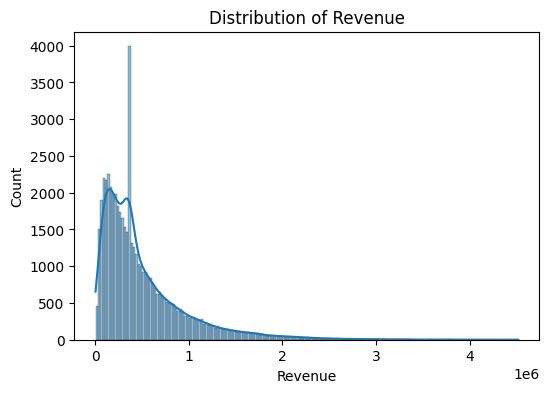

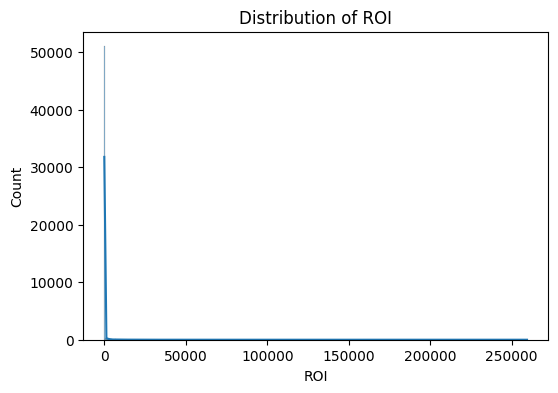

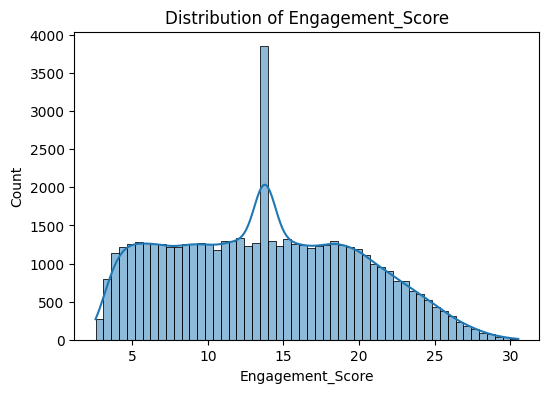

In [17]:
# 4. Univariate distribution - numeric columns
import matplotlib.pyplot as plt
import seaborn as sns

for col in ['Revenue', 'ROI', 'Engagement_Score']:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [18]:
# 5. Value counts for categorical columns
for col in ['Campaign_Type', 'Channel_Used', 'Customer_Segment', 'Target_Audience', 'Language']:
    print(df[col].value_counts())
    print()

Campaign_Type
SEO             10116
Paid Ads        10077
Email           10058
Social Media     9996
Influencer       9983
Unknown          2592
Name: count, dtype: int64

Channel_Used
Email                         2843
Facebook                      2786
Instagram                     2779
Google                        2719
WhatsApp                      2719
                              ... 
Google, Email, WhatsApp        121
Email, YouTube, Instagram      118
WhatsApp, Email, Instagram     115
YouTube, Instagram, Email      114
Email, Facebook, Instagram     113
Name: count, Length: 157, dtype: int64

Customer_Segment
Youth                    10138
Working Women            10091
Tier 2 City Customers    10016
College Students         10015
Premium Shoppers          9993
Unknown                   2569
Name: count, dtype: int64

Target_Audience
Premium Shoppers         10191
Tier 2 City Customers    10081
Youth                    10042
Working Women            10017
College Students   

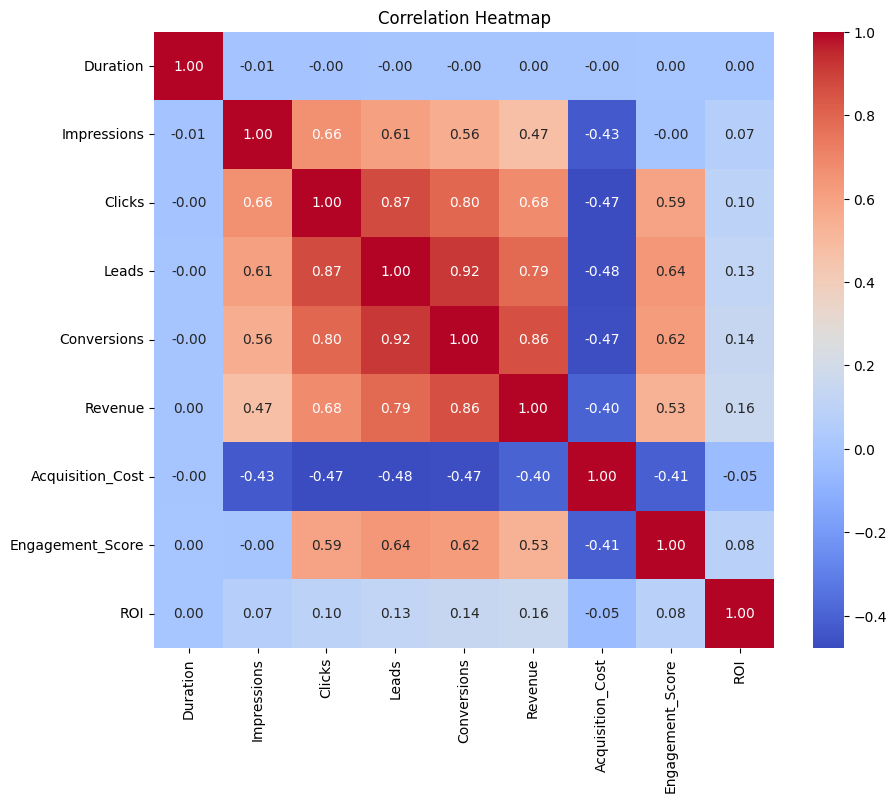

In [19]:
# 6. Correlation heatmap
numeric_cols = ['Duration', 'Impressions', 'Clicks', 'Leads',
                'Conversions', 'Revenue', 'Acquisition_Cost', 'Engagement_Score', 'ROI']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

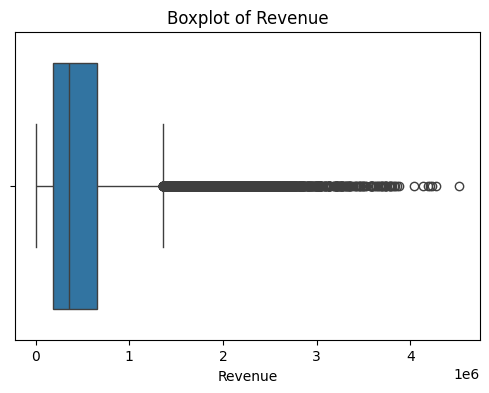

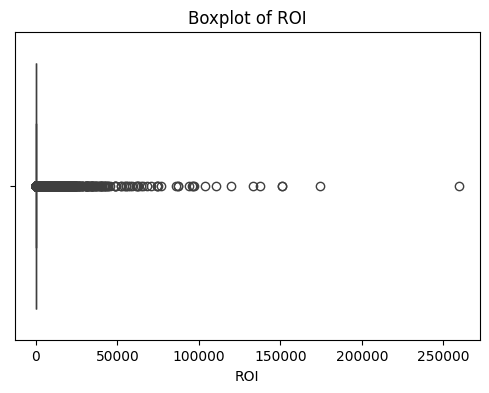

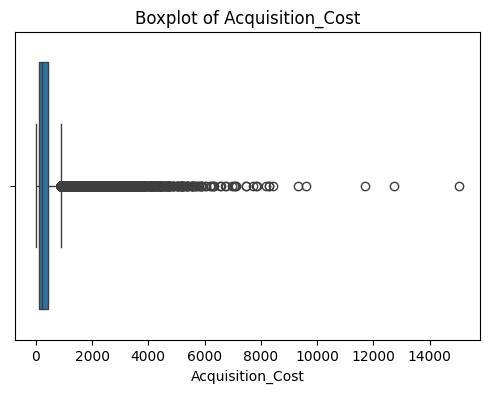

In [20]:
# 7. Boxplots for outlier detection
for col in ['Revenue', 'ROI', 'Acquisition_Cost']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [21]:
# 8. Groupby aggregations - performance by channel/segment
print(df.groupby('Channel_Used')['Revenue'].mean().sort_values(ascending=False))
print()
print(df.groupby('Campaign_Type')['ROI'].mean().sort_values(ascending=False))
print()
print(df.groupby('Customer_Segment')['Conversions'].sum().sort_values(ascending=False))

Channel_Used
Google, Facebook, Email        592107.439189
YouTube, Email, WhatsApp       582585.877622
Instagram, YouTube, Email      582371.886029
YouTube, Instagram, Email      577739.750000
Instagram, Facebook, Google    573342.802239
                                   ...      
YouTube, Google, WhatsApp      431712.386364
Facebook, WhatsApp, Google     427136.617834
Facebook, YouTube, Email       423387.804511
Email, YouTube, Instagram      420831.588983
Email, Facebook, Instagram     412858.628319
Name: Revenue, Length: 157, dtype: float64

Campaign_Type
SEO             302.356220
Paid Ads        281.916225
Influencer      274.458593
Email           269.120303
Social Media    262.722509
Unknown         242.802634
Name: ROI, dtype: float64

Customer_Segment
Youth                    10493648.0
Working Women            10341443.8
Tier 2 City Customers    10331146.4
College Students         10308361.4
Premium Shoppers         10132124.4
Unknown                   2626479.6
Name: Conver

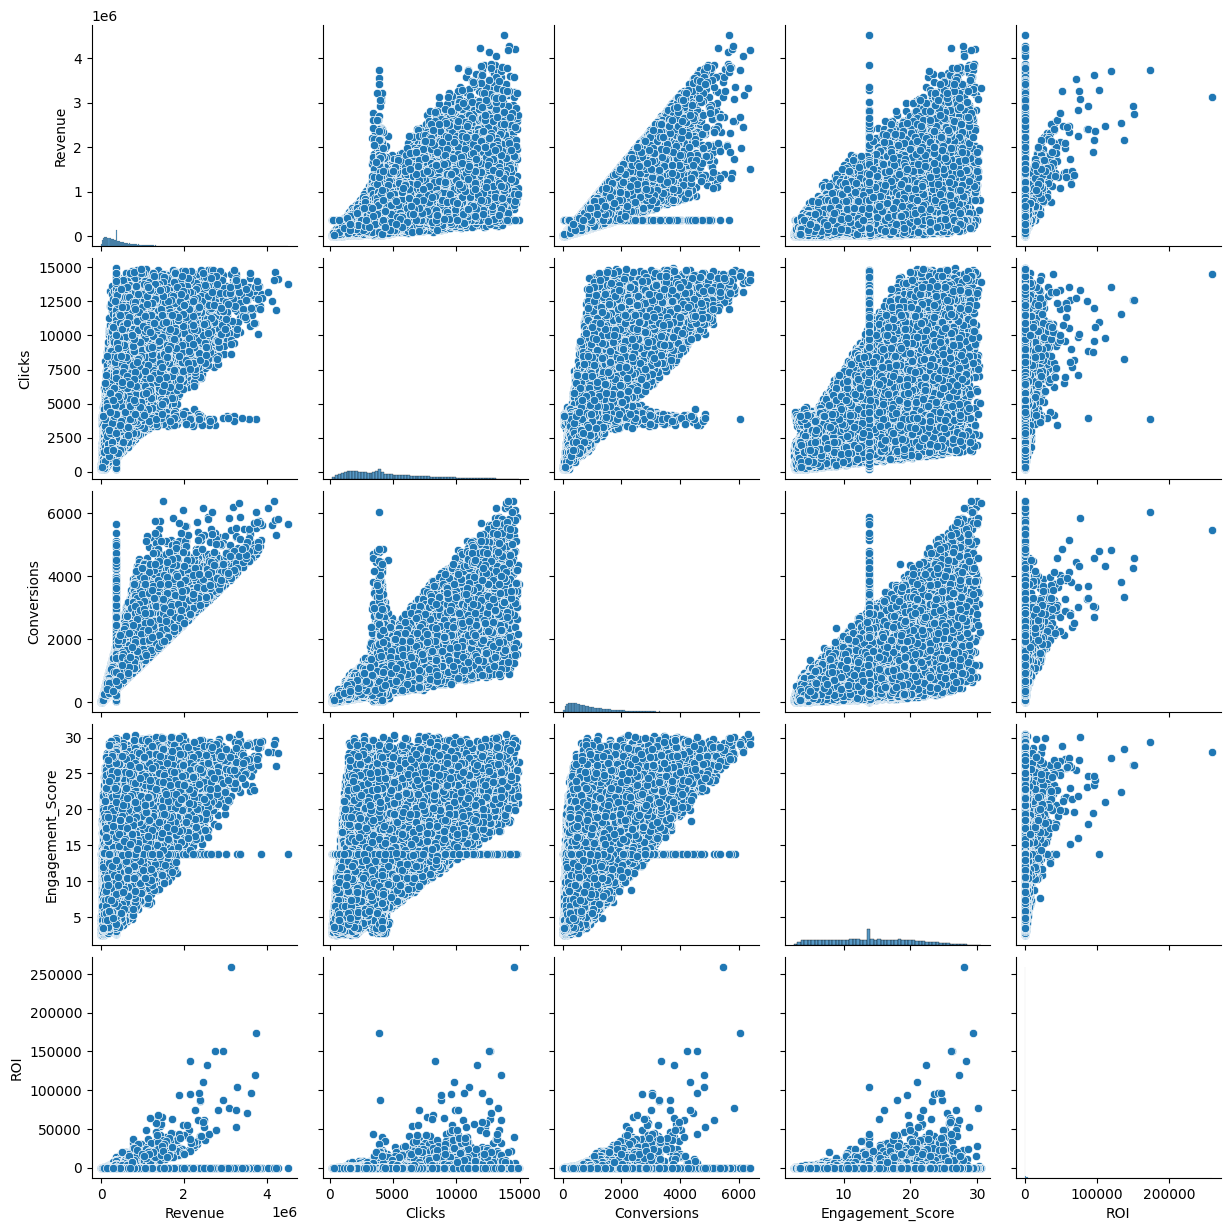

In [22]:
# 1. Pairplot - relationships between key numeric variables
sns.pairplot(df[['Revenue', 'Clicks', 'Conversions', 'Engagement_Score', 'ROI']])
plt.show()

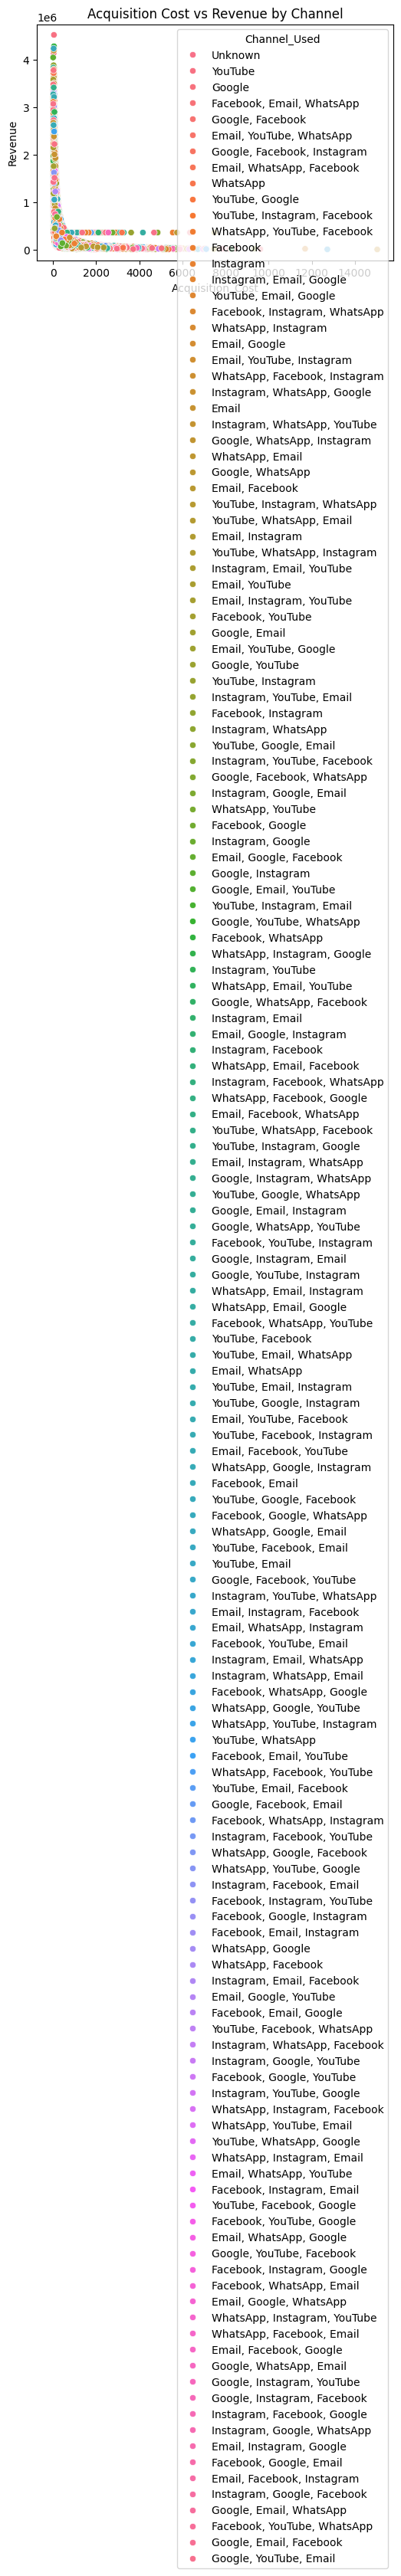

In [23]:
# 2. Scatter plot - Acquisition Cost vs Revenue
plt.figure(figsize=(6,4))
sns.scatterplot(x='Acquisition_Cost', y='Revenue', data=df, hue='Channel_Used')
plt.title('Acquisition Cost vs Revenue by Channel')
plt.show()

In [24]:
# 3. Skewness check for numeric columns
print(df[numeric_cols].skew())

Duration            -0.008048
Impressions         -0.001608
Clicks               0.877249
Leads                1.235397
Conversions          1.595017
Revenue              2.158726
Acquisition_Cost     5.329273
Engagement_Score     0.172189
ROI                 31.862802
dtype: float64


In [25]:
# 4. Top/bottom performing campaigns
print("Top 5 by Revenue:")
print(df.nlargest(5, 'Revenue')[['Campaign_ID', 'Channel_Used', 'Revenue', 'ROI']])

print("\nBottom 5 by Revenue:")
print(df.nsmallest(5, 'Revenue')[['Campaign_ID', 'Channel_Used', 'Revenue', 'ROI']])

Top 5 by Revenue:
        Campaign_ID        Channel_Used    Revenue    ROI
41309  TI-CMP-42309             YouTube  4517478.0  16.78
32733  TI-CMP-33733  Facebook, WhatsApp  4277700.0  14.63
51788  TI-CMP-52788     Facebook, Email  4231273.0  41.90
26796  TI-CMP-27796     YouTube, Google  4207876.0  19.29
48375  TI-CMP-49375               Email  4187248.0  17.07

Bottom 5 by Revenue:
        Campaign_ID                 Channel_Used  Revenue   ROI
28039  TI-CMP-29039                        Email   3895.0 -0.99
19738  TI-CMP-20738   Instagram, WhatsApp, Email   6072.0 -0.98
21313  TI-CMP-22313                    Instagram   6240.0 -0.95
14259  TI-CMP-15259  WhatsApp, Facebook, YouTube   7245.0 -0.90
46232  TI-CMP-47232                     WhatsApp   7884.0 -0.95


In [26]:
# 5. Cross-tabulation - Campaign_Type vs Channel_Used
pd.crosstab(df['Campaign_Type'], df['Channel_Used'])

Channel_Used,Email,"Email, Facebook","Email, Facebook, Google","Email, Facebook, Instagram","Email, Facebook, WhatsApp","Email, Facebook, YouTube","Email, Google","Email, Google, Facebook","Email, Google, Instagram","Email, Google, WhatsApp",...,"YouTube, Instagram","YouTube, Instagram, Email","YouTube, Instagram, Facebook","YouTube, Instagram, Google","YouTube, Instagram, WhatsApp","YouTube, WhatsApp","YouTube, WhatsApp, Email","YouTube, WhatsApp, Facebook","YouTube, WhatsApp, Google","YouTube, WhatsApp, Instagram"
Campaign_Type,,,,,,,,,,,,,,,,,,,,,
Email,579,92,25,11,19,18,126,26,31,32,...,117,17,30,21,27,120,17,27,22,29
Influencer,573,106,21,23,26,33,105,31,26,29,...,126,23,22,32,26,112,31,28,28,30
Paid Ads,511,132,24,22,39,28,106,25,32,23,...,121,28,36,21,30,115,30,24,25,24
SEO,499,108,24,24,25,27,104,34,29,24,...,125,29,27,24,25,109,33,26,31,22
Social Media,540,107,31,26,21,28,136,27,31,34,...,111,14,26,28,31,110,27,22,30,21
Unknown,141,23,6,7,7,7,37,4,3,7,...,28,3,12,2,8,35,6,11,4,6


count    52822.000000
mean         0.221672
std          0.097153
min          0.011869
25%          0.151681
50%          0.205675
75%          0.279146
max          1.553638
Name: Conversion_Rate, dtype: float64


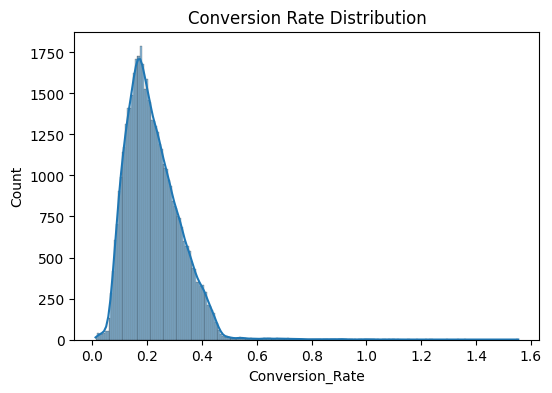

In [27]:
# 6. Conversion rate calculation (derived metric)
df['Conversion_Rate'] = df['Conversions'] / df['Clicks']
print(df['Conversion_Rate'].describe())

plt.figure(figsize=(6,4))
sns.histplot(df['Conversion_Rate'], kde=True)
plt.title('Conversion Rate Distribution')
plt.show()

In [28]:
# 7. Average metrics by Target Audience
df.groupby('Target_Audience')[['Revenue', 'ROI', 'Engagement_Score']].mean().sort_values('Revenue', ascending=False)

,Revenue,ROI,Engagement_Score
Target_Audience,,,
Unknown,508259.059701,183.790539,13.735157
Working Women,507007.097484,296.276814,13.796566
Tier 2 City Customers,506283.755977,308.464686,13.813652
Youth,506024.300339,243.510351,13.764806
Premium Shoppers,505631.669807,341.636682,13.734928
College Students,499918.835043,214.121434,13.701502


In [29]:
# 8. Check for any remaining anomalies after imputation
print("Remaining nulls:")
print(df.isnull().sum().sum())

print("\nNegative values check (shouldn't exist):")
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count} negative values")

Remaining nulls:
0

Negative values check (shouldn't exist):
ROI: 11666 negative values


In [30]:
df.to_csv('tira_cleaned.csv', index=False)